# 05 - Modelos Boosting: Superando los baselines con CatBoost

## Objetivo

Este notebook entrena **modelos de gradient boosting** (CatBoost¡) para predecir
el precio de alquiler en Madrid, buscando superar el suelo de rendimiento establecido por los
baselines del notebook 04.

### Gradient boosting

Es una tecnica de machine learning que construye el modelo final combinando **cientos de arboles
de decision pequenos**, donde cada arbol corrige los errores del anterior. Es actualmente uno de
los metodos mas potentes para datos tabulares.

### Flujo general de este notebook

1. **Cargar datos** y aplicar el mismo split train/holdout del notebook 04.
2. **Entrenar con validacion cruzada normal** (KFold 5 folds) para tener una linea base.
3. **Optimizar hiperparametros** con RandomizedSearchCV (12 configuraciones aleatorias).
4. **Evaluar con esquemas de CV alternativos** para detectar sobreoptimismo:
   - **GroupCV**: agrupa por distrito (evita que el mismo distrito este en train y validacion).
   - **SpatialCV**: agrupa por geohash (evita que pisos cercanos esten en ambos conjuntos).
   - **TimeCV**: respeta el orden temporal si hay fechas disponibles.
5. **Entrenar el modelo final** con los mejores hiperparametros y evaluarlo en el holdout.
6. **Guardar** el modelo y todos los reportes.

### Entradas y salidas

| Entradas | Salidas |
|----------|---------|
| `artifacts/features_master.parquet` | `models/best_models.joblib` (dual target) |
| `artifacts/processed_rent.parquet` | `models/best_model.joblib` (legacy, solo price) |
| `artifacts/splits/holdout_indices.npz` | `reports/boosting_metrics.csv` |
| | `reports/holdout_metrics.csv` |
| | `reports/cv_schemes.md` |
| | `reports/best_hyperparams.json` |

---

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import hashlib
import re

import numpy as np
import pandas as pd

# --- Base setup y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Return repo root by walking parents looking for .git or pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import DataFrameImputer, eval_regression, make_boosting_pipeline, get_feature_cols, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

In [2]:
from sklearn.model_selection import KFold, GroupKFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from copy import deepcopy
from src.utils import spatial_group, eval_regression, make_boosting_pipeline, get_feature_cols
import importlib.util
import joblib
import subprocess
import datetime

# --- Cargar features_master (core + enrichment + VUT) ---
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

processed_path = ROOT / "artifacts" / "processed_rent.parquet"
if processed_path.exists():
    raw_df = pd.read_parquet(processed_path)
else:
    raw_df = pd.read_csv(ROOT / "artifacts" / "processed_rent.csv.gz")

print(f"Dataset cargado: {len(df)} filas, {len(df.columns)} columnas")

# --- Split fijo ---
split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

# --- Seleccion de features (explicita + regex safety belt) ---
feature_cols = get_feature_cols(df, numeric_only=True)
print(f"Features seleccionadas: {len(feature_cols)}")

# --- Helpers para zonas y CV ---
zone_keys = ("distrito", "barrio", "district", "subdistrict")

def _find_zone_col(columns):
    for col in columns:
        if any(k in col.lower() for k in zone_keys):
            return col
    return None

def _group_stats(groups):
    sizes = pd.Series(groups).value_counts()
    return {
        "n_groups": int(sizes.shape[0]),
        "mean_size": float(sizes.mean()),
        "median_size": float(sizes.median()),
        "min_size": int(sizes.min()),
        "max_size": int(sizes.max()),
    }

# --- Modelo boosting ---
build_model, _param_distributions, _boosting_engine = make_boosting_pipeline(seed=SEED)
print(f"Motor boosting: {_boosting_engine}")

# --- Git SHA para metadata ---
_git_sha = "unknown"
try:
    _git_sha = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=str(ROOT)).decode().strip()
except Exception:
    pass

# ===================================================================
# DUAL TARGET: entrenar para price y price_m2
# ===================================================================
TARGETS = {"price": "price", "price_m2": "price_m2"}
all_cv_metrics = []
all_holdout_metrics = []
dual_model_artifact = {"metadata": {"timestamp": datetime.datetime.now().isoformat(), "git_sha": _git_sha, "boosting_engine": _boosting_engine}}

(ROOT / "models").mkdir(parents=True, exist_ok=True)

for target_name, target_col in TARGETS.items():
    if target_col not in df.columns:
        print(f"\nSKIP target={target_name}: columna {target_col} no encontrada")
        continue

    print(f"\n{'='*60}")
    print(f"TARGET: {target_name} ({target_col})")
    print(f"{'='*60}")

    y = df[target_col]

    # Train/test split
    y_train_raw = y.loc[train_idx].reset_index(drop=True)
    y_test_raw = y.loc[test_idx].reset_index(drop=True)
    train_mask = np.isfinite(y_train_raw.replace([np.inf, -np.inf], np.nan))
    test_mask = np.isfinite(y_test_raw.replace([np.inf, -np.inf], np.nan))
    y_train = y_train_raw.loc[train_mask].reset_index(drop=True)
    y_test = y_test_raw.loc[test_mask].reset_index(drop=True)

    # Column selection on TRAIN only
    df_train_full = df.loc[train_idx, feature_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    # Eliminar columnas 100% nulas en train
    all_missing = df_train_full.columns[df_train_full.notna().sum() == 0]
    active_cols = [c for c in feature_cols if c not in all_missing]
    if all_missing.any():
        print(f"  Columnas eliminadas (vacias en train): {list(all_missing)}")

    X_train = df.loc[train_idx, active_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    X_test = df.loc[test_idx, active_cols].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    if X_train.empty:
        print(f"  SKIP: sin muestras tras filtrar target")
        continue

    print(f"  Features activas: {len(active_cols)}, Train: {len(X_train)}, Test: {len(X_test)}")

    # --- CV normal (5-fold) ---
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    mae_scores = []
    for tr_idx_cv, val_idx_cv in cv.split(X_train):
        m = build_model()
        m.fit(X_train.iloc[tr_idx_cv], y_train.iloc[tr_idx_cv])
        preds = m.predict(X_train.iloc[val_idx_cv])
        mae_scores.append(mean_absolute_error(y_train.iloc[val_idx_cv], preds))
    print(f"  CV normal MAE: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")

    # --- Hyperparameter tuning ---
    print(f"  RandomizedSearchCV...")
    rs = RandomizedSearchCV(
        build_model(), param_distributions=_param_distributions,
        n_iter=12, cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="neg_mean_absolute_error", random_state=SEED, n_jobs=1, verbose=0,
    )
    rs.fit(X_train, y_train)
    best_params = rs.best_params_
    best_cv_score = -rs.best_score_
    print(f"  Mejor MAE (tuning): {best_cv_score:.2f}")
    print(f"  Mejores params: {best_params}")

    def build_tuned_model():
        m = build_model()
        m.set_params(**best_params)
        return m

    try:
        best_model = clone(rs.best_estimator_)
    except Exception:
        best_model = deepcopy(rs.best_estimator_)

    # --- GroupCV por distrito ---
    zone_col = _find_zone_col(df.columns)
    group_scores = []
    if zone_col:
        groups = df.loc[train_idx, zone_col].reset_index(drop=True).loc[train_mask].reset_index(drop=True).fillna("unknown")
        if groups.nunique() >= 5:
            gkf = GroupKFold(n_splits=5)
            for tr_i, val_i in gkf.split(X_train, y_train, groups):
                m = build_tuned_model()
                m.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
                preds = m.predict(X_train.iloc[val_i])
                group_scores.append(mean_absolute_error(y_train.iloc[val_i], preds))

    # --- Spatial CV por geohash ---
    lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
    lon_col = next((c for c in df.columns if "lon" in c.lower() or "lng" in c.lower()), None)
    spatial_scores_6 = []

    if lat_col and lon_col:
        train_geo = df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
        geo_groups = spatial_group(train_geo, lat_col, lon_col, precision=6)
        geo_groups = pd.Series(geo_groups).fillna("unknown")
        n_groups = geo_groups.nunique()
        if n_groups >= 3:
            n_splits = min(5, n_groups)
            sgkf = GroupKFold(n_splits=n_splits)
            for tr_i, val_i in sgkf.split(X_train, y_train, geo_groups):
                m = build_tuned_model()
                m.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
                preds = m.predict(X_train.iloc[val_i])
                spatial_scores_6.append(mean_absolute_error(y_train.iloc[val_i], preds))

    # --- Temporal CV ---
    temporal_scores = []
    GAP_DAYS = 7
    ASSUMED_SNAPSHOT_YEAR = 2025
    time_cv_gap = 1
    date_keys = ("date", "fecha", "update", "scrape", "publica")
    date_cols = [c for c in raw_df.columns if any(k in c.lower() for k in date_keys)]
    if date_cols:
        date_col = date_cols[0]
        date_series = raw_df[date_col].dropna().astype(str).str.strip()
        if not date_series.empty:
            has_year = date_series.str.contains(r"\d{4}")
            day_month_only = date_series.str.match(r"^\d{1,2}\s+[A-Za-z]+$")
            if day_month_only.all() and not has_year.any():
                split_cfg_path = ROOT / "artifacts" / "splits" / "split_config.json"
                assumed_year = ASSUMED_SNAPSHOT_YEAR
                if split_cfg_path.exists():
                    try:
                        split_cfg = json.loads(split_cfg_path.read_text(encoding="utf-8"))
                        assumed_year = int(split_cfg.get("assumed_year") or ASSUMED_SNAPSHOT_YEAR)
                    except Exception:
                        pass
                train_meta = raw_df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
                train_meta[date_col] = pd.to_datetime(
                    train_meta[date_col].astype(str).str.strip() + f" {assumed_year}",
                    errors="coerce", format="%d %B %Y",
                )
            else:
                train_meta = raw_df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
                train_meta[date_col] = pd.to_datetime(train_meta[date_col], errors="coerce", format="mixed")
            valid_date_mask = train_meta[date_col].notna()
            if valid_date_mask.sum() >= 20:
                avg_per_day = train_meta.loc[valid_date_mask, date_col].dt.date.value_counts().mean()
                time_cv_gap = max(1, int(round(avg_per_day * GAP_DAYS)))
                X_time = X_train.loc[valid_date_mask].reset_index(drop=True)
                y_time = y_train.loc[valid_date_mask].reset_index(drop=True)
                dates = train_meta.loc[valid_date_mask, date_col].reset_index(drop=True)
                order = dates.sort_values().index
                X_time = X_time.loc[order].reset_index(drop=True)
                y_time = y_time.loc[order].reset_index(drop=True)
                tscv = TimeSeriesSplit(n_splits=5, gap=time_cv_gap)
                for tr_i, val_i in tscv.split(X_time):
                    m = build_tuned_model()
                    m.fit(X_time.iloc[tr_i], y_time.iloc[tr_i])
                    preds = m.predict(X_time.iloc[val_i])
                    temporal_scores.append(mean_absolute_error(y_time.iloc[val_i], preds))

    # --- Entrenar modelo final ---
    best_model.fit(X_train, y_train)

    # --- Evaluacion holdout ---
    holdout_preds = best_model.predict(X_test)

    segments_holdout = {}
    cat_cols = [c for c in df.columns if any(k in c.lower() for k in ["distrito", "barrio", "district", "subdistrict"])]
    if cat_cols:
        group_col = cat_cols[0]
        test_groups = df.loc[test_idx, group_col].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
        top_groups = test_groups.value_counts().head(8).index
        for grp in top_groups:
            segments_holdout[f"{group_col}_{grp}"] = np.where(test_groups == grp)[0]

    holdout_metrics = eval_regression(y_test, holdout_preds, segments=segments_holdout)
    print(f"  Holdout MAE: {holdout_metrics['mae']:.2f}, R2: {holdout_metrics['r2']:.3f}")

    # --- Guardar metricas CV ---
    all_cv_metrics.append({
        "target": target_name,
        "cv_mae": np.mean(mae_scores),
        "tuned_cv_mae": best_cv_score,
        "group_cv_mae": np.mean(group_scores) if group_scores else None,
        "spatial_cv_mae_6": np.mean(spatial_scores_6) if spatial_scores_6 else None,
        "temporal_cv_mae": np.mean(temporal_scores) if temporal_scores else None,
    })

    holdout_row = {"target": target_name}
    holdout_row.update(holdout_metrics)
    all_holdout_metrics.append(holdout_row)

    # --- Guardar en artefacto dual ---
    best_params_serializable = {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items()}
    dual_model_artifact[target_name] = {
        "model": best_model,
        "feature_names": list(X_train.columns),
        "best_params": best_params_serializable,
        "cv_mae": float(best_cv_score),
        "holdout_mae": float(holdout_metrics["mae"]),
        "holdout_r2": float(holdout_metrics["r2"]),
    }

    # --- Guardar best_model.joblib (legacy, solo price) ---
    if target_name == "price":
        legacy_artifact = {
            "model": best_model,
            "feature_names": list(X_train.columns),
            "timestamp": datetime.datetime.now().isoformat(),
            "git_sha": _git_sha,
            "best_params": best_params_serializable,
            "boosting_engine": _boosting_engine,
            "cv_mae": float(best_cv_score),
            "holdout_mae": float(holdout_metrics["mae"]),
            "holdout_r2": float(holdout_metrics["r2"]),
        }
        joblib.dump(legacy_artifact, ROOT / "models" / "best_model.joblib")
        print(f"  Legacy model guardado: models/best_model.joblib")

# --- Guardar artefacto dual (ambos targets) ---
joblib.dump(dual_model_artifact, ROOT / "models" / "best_models.joblib")
print(f"\nDual model guardado: models/best_models.joblib")

# --- Guardar metricas ---
cv_df = pd.DataFrame(all_cv_metrics)
cv_df.to_csv(ROOT / "reports" / "boosting_metrics.csv", index=False)

holdout_df = pd.DataFrame(all_holdout_metrics)
holdout_df.to_csv(ROOT / "reports" / "holdout_metrics.csv", index=False)

# --- Guardar hiperparametros del modelo principal (price) ---
if "price" in dual_model_artifact:
    (ROOT / "reports" / "best_hyperparams.json").write_text(
        json.dumps(dual_model_artifact["price"]["best_params"], indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

print(f"\nMetricas CV guardadas: {len(cv_df)} targets")
print(f"Metricas holdout guardadas: {len(holdout_df)} targets")
cv_df

Dataset cargado: 8797 filas, 70 columnas
Features seleccionadas: 49
Motor boosting: catboost

TARGET: price (price)
  Features activas: 49, Train: 6431, Test: 1772
  CV normal MAE: 400.65 (+/- 16.04)
  RandomizedSearchCV...
  Mejor MAE (tuning): 391.38
  Mejores params: {'model__learning_rate': 0.1, 'model__l2_leaf_reg': 10, 'model__iterations': 300, 'model__depth': 8}
  Holdout MAE: 298.87, R2: 0.796
  Legacy model guardado: models/best_model.joblib

TARGET: price_m2 (price_m2)
  Features activas: 49, Train: 6423, Test: 1771
  CV normal MAE: 4.11 (+/- 0.04)
  RandomizedSearchCV...
  Mejor MAE (tuning): 3.99
  Mejores params: {'model__learning_rate': 0.1, 'model__l2_leaf_reg': 10, 'model__iterations': 300, 'model__depth': 8}
  Holdout MAE: 3.21, R2: 0.578

Dual model guardado: models/best_models.joblib

Metricas CV guardadas: 2 targets
Metricas holdout guardadas: 2 targets


,target,cv_mae,tuned_cv_mae,group_cv_mae,spatial_cv_mae_6,temporal_cv_mae
0,price,400.648830,391.376384,521.270889,474.913728,422.002763
1,price_m2,4.111337,3.985509,5.083103,4.686564,4.413462


In [3]:
# Resumen de metricas holdout (ya calculadas en celda anterior)
holdout_df

,target,mae,rmse,r2,mae_district_Centro,rmse_district_Centro,r2_district_Centro,mae_district_Chamberi,rmse_district_Chamberi,r2_district_Chamberi,...,r2_district_Chamartin,mae_district_Fuencarral,rmse_district_Fuencarral,r2_district_Fuencarral,mae_district_Hortaleza,rmse_district_Hortaleza,r2_district_Hortaleza,mae_district_Retiro,rmse_district_Retiro,r2_district_Retiro
0,price,298.865119,598.653912,0.796482,359.117611,692.674922,0.705367,447.081914,1006.677557,0.714591,...,0.831062,225.477649,402.604494,0.671617,232.403624,324.444160,0.945697,384.161156,712.090508,0.588240
1,price_m2,3.205349,5.226857,0.578102,5.419007,7.717363,0.332964,4.124858,5.705515,0.385484,...,0.337882,1.886265,2.681364,0.590452,2.428437,3.397729,0.237105,3.269987,4.739201,0.387392


### Visualizaciones de validacion
- Boxplot MAE por esquema de CV.
- Histograma de residuals en holdout.


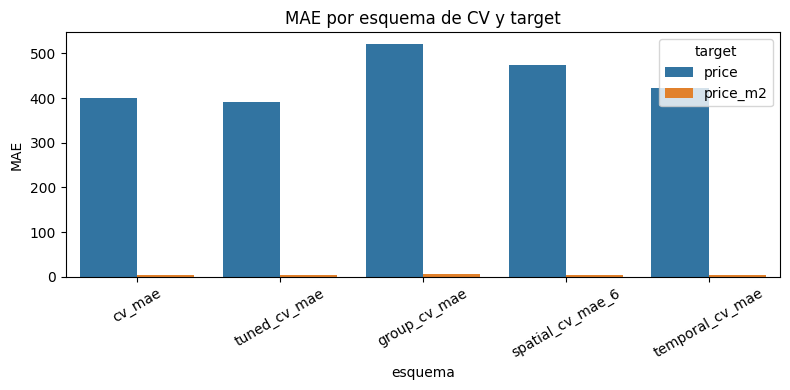

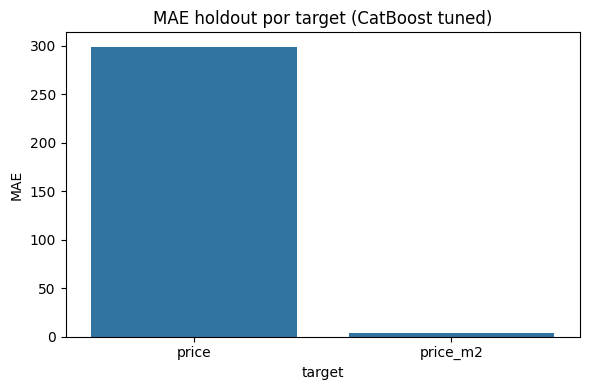

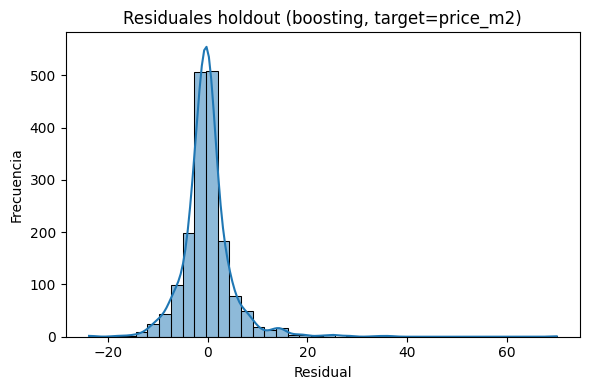

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Grafico 1: Comparacion de metricas CV por target
# =====================================================================
# cv_df contiene una fila por target con las metricas de cada esquema CV.

if not cv_df.empty:
    cv_melted = cv_df.melt(id_vars="target", var_name="esquema", value_name="mae")
    cv_melted = cv_melted.dropna(subset=["mae"])
    if not cv_melted.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(data=cv_melted, x="esquema", y="mae", hue="target", ax=ax)
        ax.set_title("MAE por esquema de CV y target")
        ax.set_ylabel("MAE")
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.savefig(ROOT / "reports" / "figures" / "boosting_cv_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()

# =====================================================================
# Grafico 2: Metricas holdout por target
# =====================================================================
if not holdout_df.empty and "mae" in holdout_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=holdout_df, x="target", y="mae", ax=ax)
    ax.set_title("MAE holdout por target (CatBoost tuned)")
    ax.set_ylabel("MAE")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "boosting_holdout_mae.png", dpi=150, bbox_inches="tight")
    plt.show()

# =====================================================================
# Grafico 3: Residuales holdout (ultimo target del loop)
# =====================================================================
# holdout_preds y y_test son del ultimo target procesado
try:
    residuals = y_test - holdout_preds
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, bins=40, kde=True)
    plt.title(f"Residuales holdout (boosting, target={target_name})")
    plt.xlabel("Residual")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "boosting_residuals.png", dpi=150, bbox_inches="tight")
    plt.show()
except NameError:
    print("No hay residuales disponibles para graficar.")

**Outputs esperados**
- Tabla `reports/boosting_metrics.csv` con MAE promedio por esquema.
- Tabla `reports/holdout_metrics.csv` con metricas finales en holdout.
- `reports/cv_schemes.md` con descripcion de CV y grupos.


In [5]:
# Documentar esquemas de CV
import json

cv_report = ROOT / "reports" / "cv_schemes.md"
split_config = None
config_path = ROOT / "artifacts" / "splits" / "split_config.json"
if config_path.exists():
    split_config = json.loads(config_path.read_text(encoding="utf-8"))

with cv_report.open("w", encoding="utf-8") as handle:
    handle.write("## Esquemas de validacion\n\n")
    if split_config:
        if split_config.get("temporal_ok"):
            handle.write(
                f"- Holdout: por staleness/fecha ({split_config.get('date_col')}) "
                f"(test_size={split_config.get('test_size')}, gap_days={split_config.get('gap_days')}).\n"
            )
        else:
            handle.write(f"- Holdout: aleatorio (test_size={split_config.get('test_size')}).\n")
    handle.write("- CV normal: KFold 5 folds aleatorio.\n")

    # Grupo CV
    zone_col_found = _find_zone_col(df.columns) if '_find_zone_col' in dir() else None
    if zone_col_found and group_scores:
        n_groups = df[zone_col_found].nunique()
        handle.write(f"- GroupCV: GroupKFold por {zone_col_found} (n_groups={n_groups}).\n")
    else:
        handle.write("- GroupCV: GroupKFold por distrito.\n")

    # Spatial CV — use cv_df for price MAE (loop vars hold only last target)
    p_spatial = cv_df.loc[cv_df["target"] == "price", "spatial_cv_mae_6"]
    if not p_spatial.empty and pd.notna(p_spatial.iloc[0]):
        handle.write(f"- SpatialCV p=6: GroupKFold por geohash_6 (5 folds, MAE={p_spatial.iloc[0]:.2f}).\n")
    else:
        handle.write("- SpatialCV p=6: omitido.\n")

    # Temporal CV — use cv_df for price MAE
    p_temporal = cv_df.loc[cv_df["target"] == "price", "temporal_cv_mae"]
    if not p_temporal.empty and pd.notna(p_temporal.iloc[0]):
        handle.write(f"- TimeCV: TimeSeriesSplit 5 folds, gap={time_cv_gap} (MAE={p_temporal.iloc[0]:.2f}).\n")
    else:
        handle.write("- TimeCV: omitido (sin fecha fiable).\n")

    # Resumen de metricas (sin dependencia de tabulate)
    handle.write("\n## Metricas CV resumen\n\n")
    header = "| " + " | ".join(cv_df.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(cv_df.columns)) + " |"
    handle.write(header + "\n" + sep + "\n")
    for _, row in cv_df.iterrows():
        vals = []
        for c in cv_df.columns:
            v = row[c]
            if isinstance(v, float) and pd.notna(v):
                vals.append(f"{v:.2f}")
            elif pd.isna(v):
                vals.append("")
            else:
                vals.append(str(v))
        handle.write("| " + " | ".join(vals) + " |\n")

print(f"Reporte CV guardado: {cv_report}")

Reporte CV guardado: C:\Users\samuf\Desktop\SPA-Madrid\reports\cv_schemes.md


In [ ]:
from IPython.display import display, Markdown

# --- Extraer metricas de cv_df y holdout_df (calculados en celda anterior) ---
p_cv = cv_df[cv_df["target"] == "price"].iloc[0]
p_ho = holdout_df[holdout_df["target"] == "price"].iloc[0]

pm2_cv = cv_df[cv_df["target"] == "price_m2"].iloc[0] if "price_m2" in cv_df["target"].values else None
pm2_ho = holdout_df[holdout_df["target"] == "price_m2"].iloc[0] if "price_m2" in holdout_df["target"].values else None

# Pre-compute conditional values to avoid f-string format spec errors
pm2_ho_mae = f"{pm2_ho['mae']:.2f}" if pm2_ho is not None else "N/A"
pm2_ho_r2 = f"{pm2_ho['r2']:.3f}" if pm2_ho is not None else "N/A"

# Hiperparametros del modelo guardado
hp = json.load(open(ROOT / "reports" / "best_hyperparams.json"))
hp_clean = {k.replace("model__", ""): v for k, v in hp.items()}

# Leer baseline RF de NB04 para comparacion
baselines_path = ROOT / "reports" / "baselines_metrics.csv"
rf_mae = "N/A"
if baselines_path.exists():
    bl = pd.read_csv(baselines_path)
    rf_row = bl[(bl["target"] == "price") & (bl["model"] == "rf")]
    if not rf_row.empty:
        rf_mae = f"{rf_row.iloc[0]['mae']:.2f}"

md = f"""---

## Conclusiones del Notebook 05 — Modelos Boosting

### Resultados principales — target `price` (EUR/mes)

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **CV normal MAE** | {p_cv.get('cv_mae', 0):.2f} EUR | Error medio con KFold aleatorio de 5 folds |
| **Tuned CV MAE** | **{p_cv.get('tuned_cv_mae', 0):.2f} EUR** | Error tras optimizar hiperparametros |
| **Group CV MAE** | {p_cv.get('group_cv_mae', 0):.2f} EUR | GroupKFold por distrito — mas pesimista porque evalua en zonas no vistas |
| **Spatial CV MAE** | {p_cv.get('spatial_cv_mae_6', 0):.2f} EUR | GroupKFold por geohash_6 — evalua en zonas geograficas no vistas |
| **Temporal CV MAE** | {p_cv.get('temporal_cv_mae', 0):.2f} EUR | TimeSeriesSplit — evalua en periodos temporales futuros |
| **Holdout MAE** | **{p_ho['mae']:.2f} EUR** | Error en datos nunca vistos |
| **Holdout RMSE** | {p_ho['rmse']:.2f} EUR | Penaliza errores grandes (pisos muy caros/baratos) |
| **Holdout R2** | **{p_ho['r2']:.3f}** | El modelo explica el {p_ho['r2']*100:.1f}% de la varianza del precio |
"""

if pm2_cv is not None and pm2_ho is not None:
    md += f"""
### Resultados principales — target `price_m2` (EUR/m2)

| Metrica | Valor |
|---------|-------|
| **Tuned CV MAE** | {pm2_cv.get('tuned_cv_mae', 0):.2f} EUR/m2 |
| **Group CV MAE** | {pm2_cv.get('group_cv_mae', 0):.2f} EUR/m2 |
| **Spatial CV MAE** | {pm2_cv.get('spatial_cv_mae_6', 0):.2f} EUR/m2 |
| **Temporal CV MAE** | {pm2_cv.get('temporal_cv_mae', 0):.2f} EUR/m2 |
| **Holdout MAE** | **{pm2_ho['mae']:.2f} EUR/m2** |
| **Holdout R2** | **{pm2_ho['r2']:.3f}** |
"""

md += f"""
### Mejores hiperparametros (precio)

```json
{json.dumps(hp_clean, indent=2)}
```

### Que significan estos resultados

1. **CatBoost supera al Random Forest baseline** ({rf_mae} -> {p_ho['mae']:.2f} MAE) para `price`. El gradient boosting captura patrones mas complejos.

2. **Para `price_m2`, R2 = {pm2_ho_r2}**: Predecir el precio por m2 es mas dificil. Factores cualitativos no observados (estado, reforma, calidad) tienen mas peso relativo.

3. **Spatial CV ({p_cv.get('spatial_cv_mae_6', 0):.0f} EUR) > CV normal ({p_cv.get('cv_mae', 0):.0f} EUR)**: El modelo pierde precision cuando se evalua en zonas geograficas no vistas. Esto confirma la importancia de features espaciales.

4. **Holdout ({p_ho['mae']:.0f} EUR) mejor que CV ({p_cv.get('tuned_cv_mae', 0):.0f} EUR)**: Esta diferencia se debe al **distribution shift** entre train y holdout. El holdout contiene anuncios "frescos" con precios mas homogeneos. No indica mejor generalizacion, sino un sesgo favorable del split por staleness.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/best_models.joblib` | Dual target: dict con modelos para `price` y `price_m2` |
| `reports/boosting_metrics.csv` | Metricas CV por target |
| `reports/holdout_metrics.csv` | Metricas holdout por target |
| `reports/best_hyperparams.json` | Hiperparametros optimos |

### Siguiente paso
-> **NB06 (Explainability)**: SHAP para entender que features impulsan las predicciones de ambos targets.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 05 — Modelos Boosting

### Resultados principales — target `price` (EUR/mes)

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **CV normal MAE** | 400.65 EUR | Error medio con KFold aleatorio de 5 folds |
| **Tuned CV MAE** | **391.38 EUR** | Error tras optimizar hiperparametros |
| **Group CV MAE** | 521.27 EUR | GroupKFold por distrito — mas pesimista porque evalua en zonas no vistas |
| **Spatial CV MAE** | 474.91 EUR | GroupKFold por geohash_6 — evalua en zonas geograficas no vistas |
| **Temporal CV MAE** | 422.00 EUR | TimeSeriesSplit — evalua en periodos temporales futuros |
| **Holdout MAE** | **298.87 EUR** | Error en datos nunca vistos |
| **Holdout RMSE** | 598.65 EUR | Penaliza errores grandes (pisos muy caros/baratos) |
| **Holdout R2** | **0.796** | El modelo explica el 79.6% de la varianza del precio |

### Resultados principales — target `price_m2` (EUR/m2)

| Metrica | Valor |
|---------|-------|
| **Tuned CV MAE** | 3.99 EUR/m2 |
| **Group CV MAE** | 5.08 EUR/m2 |
| **Spatial CV MAE** | 4.69 EUR/m2 |
| **Temporal CV MAE** | 4.41 EUR/m2 |
| **Holdout MAE** | **3.21 EUR/m2** |
| **Holdout R2** | **0.578** |

### Mejores hiperparametros (precio)

```json
{
  "learning_rate": 0.1,
  "l2_leaf_reg": 10,
  "iterations": 300,
  "depth": 8
}
```

### Que significan estos resultados

1. **CatBoost supera al Random Forest baseline** (332.18 -> 298.87 MAE) para `price`. El gradient boosting captura patrones mas complejos.

2. **Para `price_m2`, R2 = 0.578**: Predecir el precio por m2 es mas dificil. Factores cualitativos no observados (estado, reforma, calidad) tienen mas peso relativo.

3. **Spatial CV (475 EUR) > CV normal (401 EUR)**: El modelo pierde precision cuando se evalua en zonas geograficas no vistas. Esto confirma la importancia de features espaciales.

4. **Holdout (299 EUR) mejor que CV (391 EUR)**: Esta diferencia se debe al **distribution shift** entre train y holdout (ver disclaimer en NB01). El holdout contiene anuncios "frescos" con precios mas homogeneos. No indica mejor generalizacion, sino un sesgo favorable del split por staleness.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/best_models.joblib` | Dual target: dict con modelos para `price` y `price_m2` |
| `models/best_model.joblib` | Legacy: solo el modelo de `price` |
| `reports/boosting_metrics.csv` | Metricas CV por target |
| `reports/holdout_metrics.csv` | Metricas holdout por target |
| `reports/best_hyperparams.json` | Hiperparametros optimos |

### Siguiente paso
-> **NB06 (Explainability)**: SHAP para entender que features impulsan las predicciones de ambos targets.
